# HeatShield AI
## Data Cleaning & Exploratory Data Analysis (EDA)

Objectif :
Nettoyer le dataset météo Algérie et explorer les premières tendances
liées au risque d'incendie pendant les vagues de chaleur.

Fichier source :     
`data/raw/algeria_weather_with_risk.csv`

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("seaborn-v0_8")

In [33]:
DATA_PATH = "../data/raw/algeria_weather_with_risk.csv"
df = pd.read_csv(DATA_PATH)
df.head()

,date,temp_max,temp_min,temp_mean,humidity,wind_max,rain,et0,vpd_max,radiation,wilaya_code,wilaya_nom,latitude,longitude,year,risk_score,risk_level
0,2019-05-01,38.7,22.9,31.6,13,28.8,0.0,11.14,6.37,25.84,1,Adrar,27.8742,-0.2939,2019,86.0,Critique
1,2019-05-02,38.4,28.8,33.5,13,43.0,0.0,14.13,6.09,24.42,1,Adrar,27.8742,-0.2939,2019,96.0,Critique
2,2019-05-03,33.9,22.7,28.9,14,31.7,0.0,10.78,4.80,26.73,1,Adrar,27.8742,-0.2939,2019,73.0,Élevé
3,2019-05-04,32.2,21.4,27.1,25,26.2,0.0,8.72,3.94,25.43,1,Adrar,27.8742,-0.2939,2019,55.0,Élevé
4,2019-05-05,33.8,20.6,28.2,19,20.0,0.0,8.87,4.58,26.18,1,Adrar,27.8742,-0.2939,2019,58.0,Élevé


In [34]:
print("Shape:", df.shape)
print("\nColonnes:", df.columns.tolist())
print("\nTypes:")
print(df.dtypes)

Shape: (64032, 17)

Colonnes: ['date', 'temp_max', 'temp_min', 'temp_mean', 'humidity', 'wind_max', 'rain', 'et0', 'vpd_max', 'radiation', 'wilaya_code', 'wilaya_nom', 'latitude', 'longitude', 'year', 'risk_score', 'risk_level']

Types:
date               str
temp_max       float64
temp_min       float64
temp_mean      float64
humidity         int64
wind_max       float64
rain           float64
et0            float64
vpd_max        float64
radiation      float64
wilaya_code      int64
wilaya_nom         str
latitude       float64
longitude      float64
year             int64
risk_score     float64
risk_level         str
dtype: object


In [35]:
print("Nombre de wilayas:", df["wilaya_nom"].nunique())
print("Liste des wilayas:")
print(sorted(df["wilaya_nom"].unique()))

print("\nAnnées:", sorted(df["year"].unique()))
print("Nombre d'années:", df["year"].nunique())

Nombre de wilayas: 58
Liste des wilayas:
['Adrar', 'Alger', 'Annaba', 'Aïn Defla', 'Aïn Témouchent', 'Batna', 'Biskra', 'Blida', 'Bordj Badji Mokhtar', 'Bordj Bou Arréridj', 'Bouira', 'Boumerdès', 'Béchar', 'Béjaïa', 'Béni Abbès', 'Chlef', 'Constantine', 'Djanet', 'Djelfa', 'El Bayadh', "El M'Ghair", 'El Meniaa', 'El Oued', 'El Tarf', 'Ghardaïa', 'Guelma', 'Illizi', 'In Guezzam', 'In Salah', 'Jijel', 'Khenchela', 'Laghouat', "M'Sila", 'Mascara', 'Mila', 'Mostaganem', 'Médéa', 'Naâma', 'Oran', 'Ouargla', 'Ouled Djellal', 'Oum El Bouaghi', 'Relizane', 'Saïda', 'Sidi Bel Abbès', 'Skikda', 'Souk Ahras', 'Sétif', 'Tamanrasset', 'Tiaret', 'Timimoun', 'Tindouf', 'Tipaza', 'Tissemsilt', 'Tizi Ouzou', 'Tlemcen', 'Touggourt', 'Tébessa']

Années: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Nombre d'années: 6


In [36]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

Series([], dtype: int64)

In [37]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["wilaya_nom", "date"]).reset_index(drop=True)
df.head()

,date,temp_max,temp_min,temp_mean,humidity,wind_max,rain,et0,vpd_max,radiation,wilaya_code,wilaya_nom,latitude,longitude,year,risk_score,risk_level
0,2019-05-01,38.7,22.9,31.6,13,28.8,0.0,11.14,6.37,25.84,1,Adrar,27.8742,-0.2939,2019,86.0,Critique
1,2019-05-02,38.4,28.8,33.5,13,43.0,0.0,14.13,6.09,24.42,1,Adrar,27.8742,-0.2939,2019,96.0,Critique
2,2019-05-03,33.9,22.7,28.9,14,31.7,0.0,10.78,4.80,26.73,1,Adrar,27.8742,-0.2939,2019,73.0,Élevé
3,2019-05-04,32.2,21.4,27.1,25,26.2,0.0,8.72,3.94,25.43,1,Adrar,27.8742,-0.2939,2019,55.0,Élevé
4,2019-05-05,33.8,20.6,28.2,19,20.0,0.0,8.87,4.58,26.18,1,Adrar,27.8742,-0.2939,2019,58.0,Élevé


In [38]:
important_cols = [
    "temp_max", "humidity", "wind_max", "rain",
    "et0", "vpd_max", "radiation", "risk_score"
]

df[important_cols].describe()

,temp_max,humidity,wind_max,rain,et0,vpd_max,radiation,risk_score
count,64032.000000,64032.000000,64032.000000,64032.000000,64032.000000,64032.000000,64032.000000,64032.000000
mean,32.657776,43.395068,19.369593,0.450061,6.534022,4.126738,22.662307,41.581163
std,6.728661,22.473448,6.816372,2.307069,2.567409,2.168284,4.785329,28.739201
min,10.100000,4.000000,5.400000,0.000000,0.500000,0.100000,2.610000,0.000000
25%,27.800000,23.000000,14.400000,0.000000,4.660000,2.350000,19.410000,16.000000
50%,32.700000,41.000000,17.800000,0.000000,6.190000,3.820000,23.970000,37.000000
75%,37.800000,63.000000,23.100000,0.000000,8.160000,5.640000,26.580000,66.000000
max,50.700000,99.000000,59.800000,69.500000,18.000000,12.300000,30.810000,100.000000


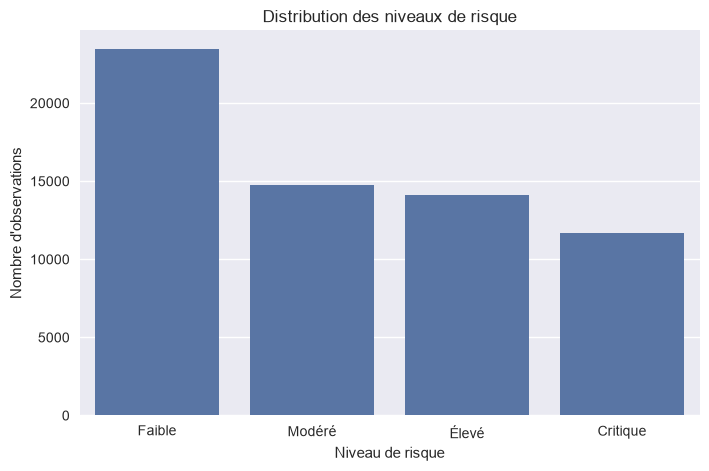

In [39]:
risk_counts = df["risk_level"].value_counts()
risk_counts
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="risk_level", order=["Faible","Modéré","Élevé","Critique"])
plt.title("Distribution des niveaux de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Nombre d'observations")
plt.show()

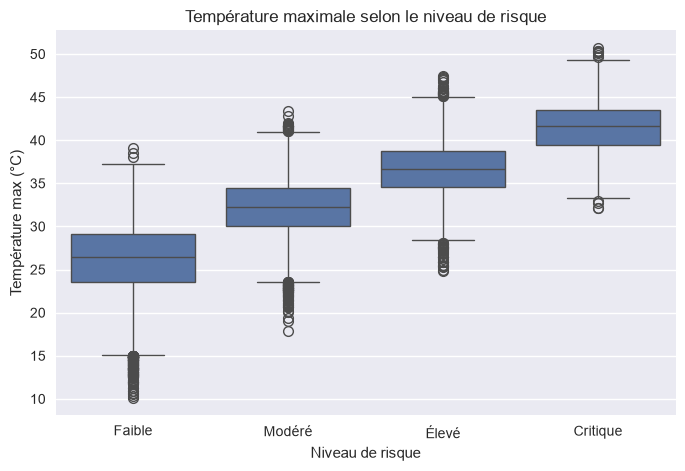

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="risk_level", y="temp_max",
            order=["Faible","Modéré","Élevé","Critique"])
plt.title("Température maximale selon le niveau de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Température max (°C)")
plt.show()

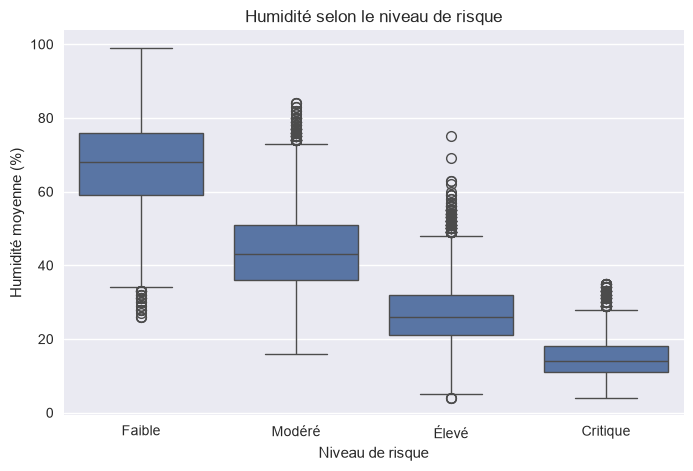

In [41]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="risk_level", y="humidity",
            order=["Faible","Modéré","Élevé","Critique"])
plt.title("Humidité selon le niveau de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Humidité moyenne (%)")
plt.show()

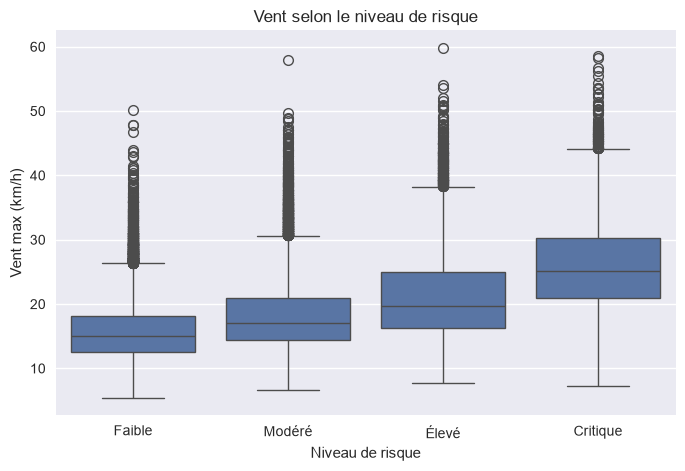

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="risk_level", y="wind_max",
            order=["Faible","Modéré","Élevé","Critique"])
plt.title("Vent selon le niveau de risque")
plt.xlabel("Niveau de risque")
plt.ylabel("Vent max (km/h)")
plt.show()

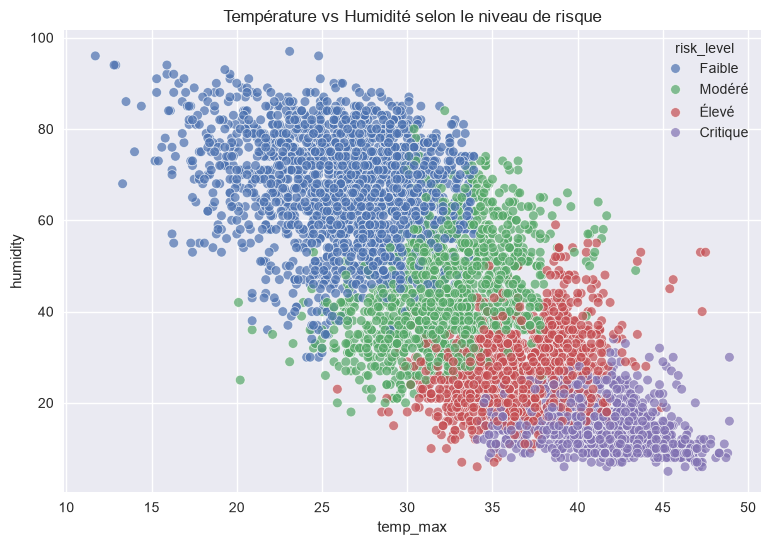

In [43]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    data=df.sample(min(5000, len(df)), random_state=42),
    x="temp_max", y="humidity", hue="risk_level",
    hue_order=["Faible","Modéré","Élevé","Critique"],
    alpha=0.7
)
plt.title("Température vs Humidité selon le niveau de risque")
plt.show()

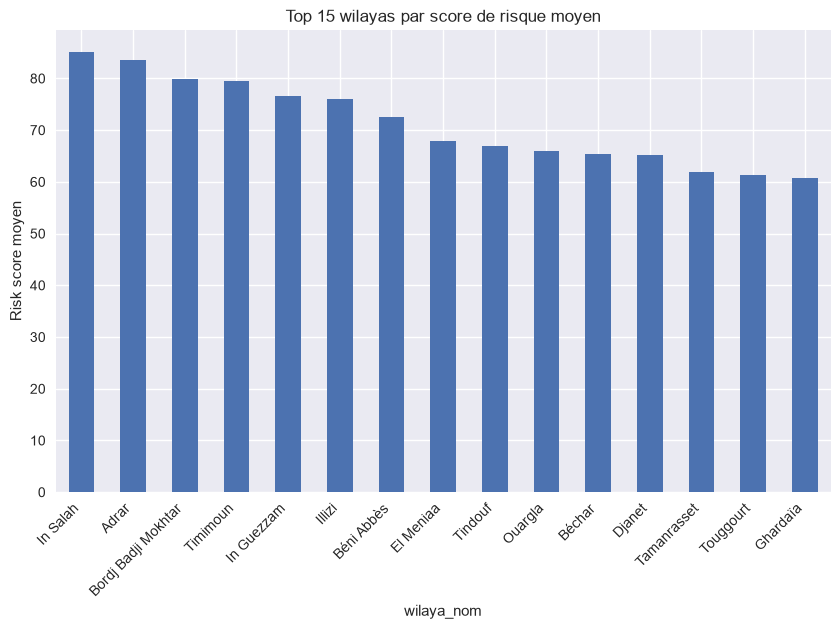

In [44]:
wilaya_risk = (
    df.groupby("wilaya_nom")["risk_score"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10,6))
wilaya_risk.plot(kind="bar")
plt.title("Top 15 wilayas par score de risque moyen")
plt.ylabel("Risk score moyen")
plt.xticks(rotation=45, ha="right")
plt.show()

In [45]:
OUTPUT_PATH = "../data/processed/algeria_weather_clean_v1.csv"
df.to_csv(OUTPUT_PATH, index=False)
print("Fichier sauvegardé:", OUTPUT_PATH)

Fichier sauvegardé: ../data/processed/algeria_weather_clean_v1.csv
